In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

import scipy.cluster.hierarchy as sch

sns.set(style="whitegrid")

In [27]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [28]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

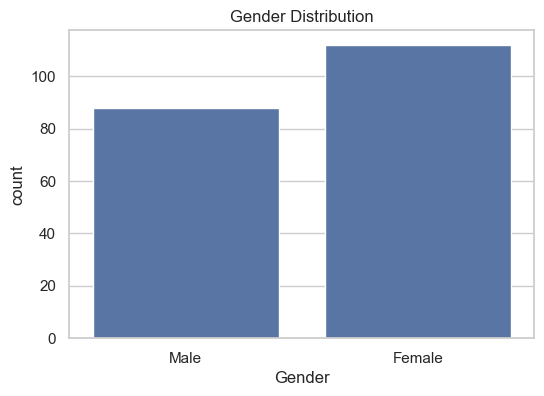

Gender
Female    112
Male       88
Name: count, dtype: int64

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

df['Gender'].value_counts()

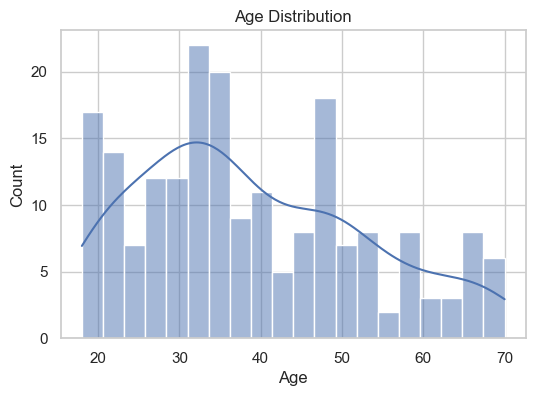

In [30]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

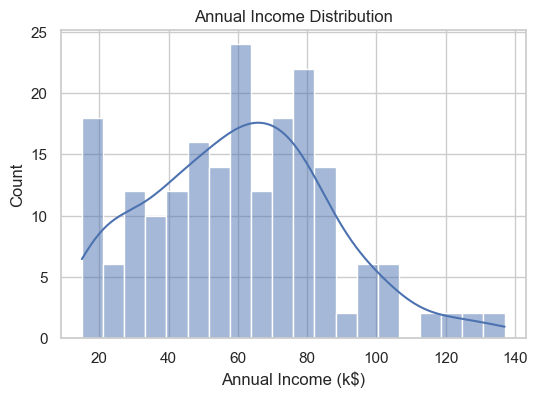

In [31]:
plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

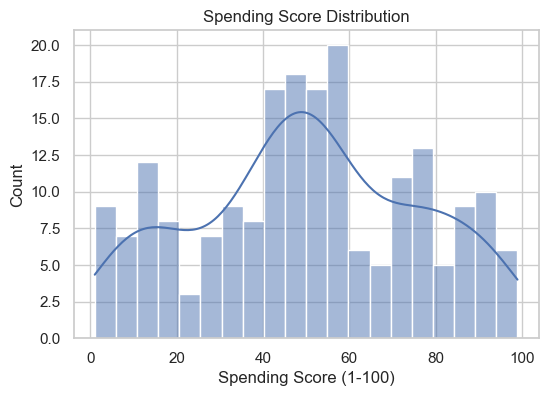

In [32]:
plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

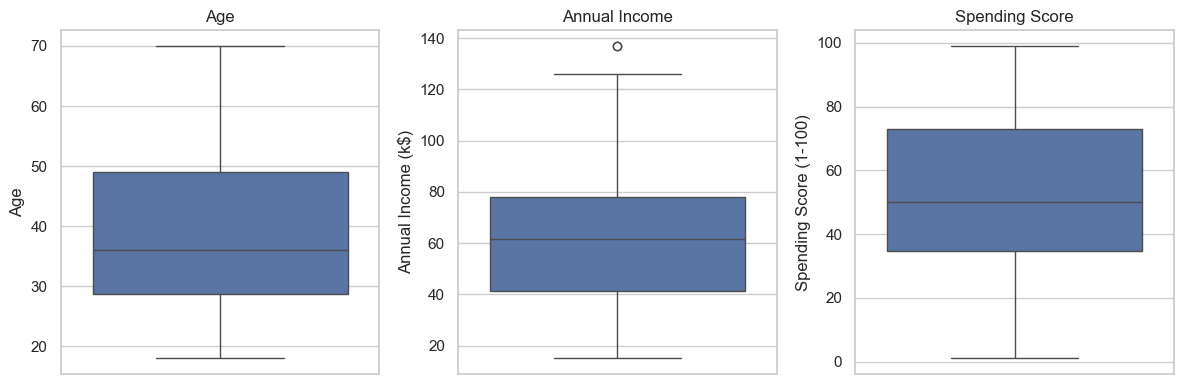

In [8]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(y=df['Age'])
plt.title("Age")

plt.subplot(1,3,2)
sns.boxplot(y=df['Annual Income (k$)'])
plt.title("Annual Income")

plt.subplot(1,3,3)
sns.boxplot(y=df['Spending Score (1-100)'])
plt.title("Spending Score")

plt.tight_layout()
plt.show()

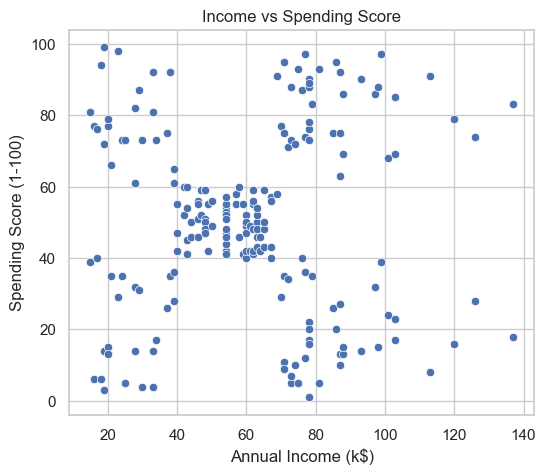

In [9]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title("Income vs Spending Score")
plt.show()

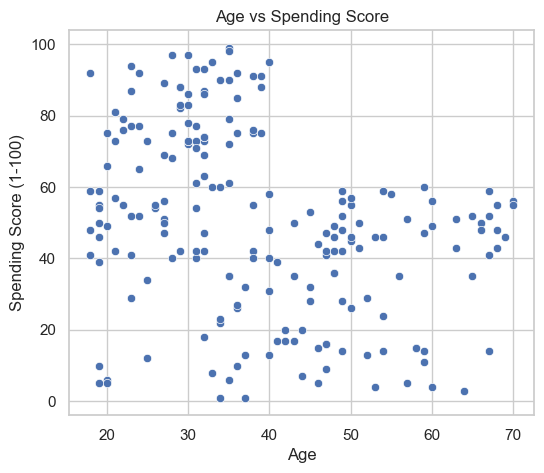

In [10]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=df)
plt.title("Age vs Spending Score")
plt.show()

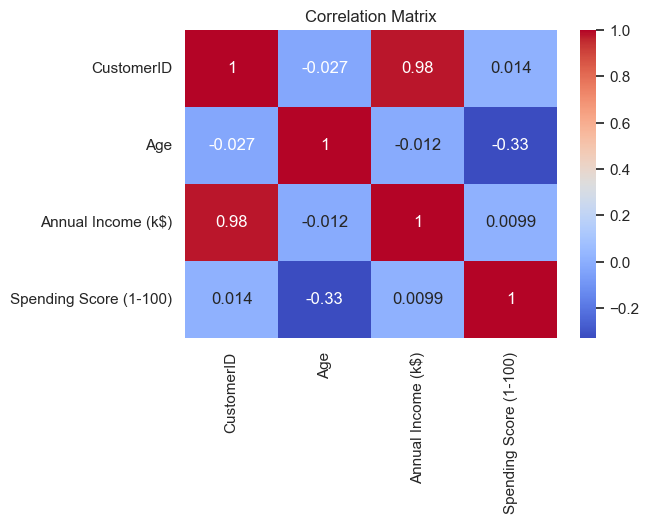

In [11]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [12]:
df['Age Group'] = pd.cut(df['Age'], bins=[18,30,40,50,60,70])

groups = [group['Spending Score (1-100)'].values for name, group in df.groupby('Age Group')]
f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA p-value:", p_value)

ANOVA p-value: 3.7876233811106496e-09


In [13]:
corr, p_value = stats.pearsonr(df['Annual Income (k$)'], df['Spending Score (1-100)'])
print("Pearson Correlation:", corr)
print("p-value:", p_value)

Pearson Correlation: 0.009902848094037619
p-value: 0.8893134370273993


In [14]:
male_income = df[df['Gender']=='Male']['Annual Income (k$)']
female_income = df[df['Gender']=='Female']['Annual Income (k$)']

t_stat, p_value = stats.ttest_ind(male_income, female_income)
print("T-test p-value:", p_value)

T-test p-value: 0.4275524939992786


In [15]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

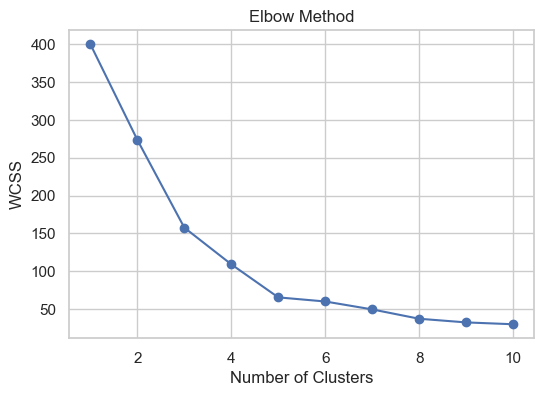

In [16]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

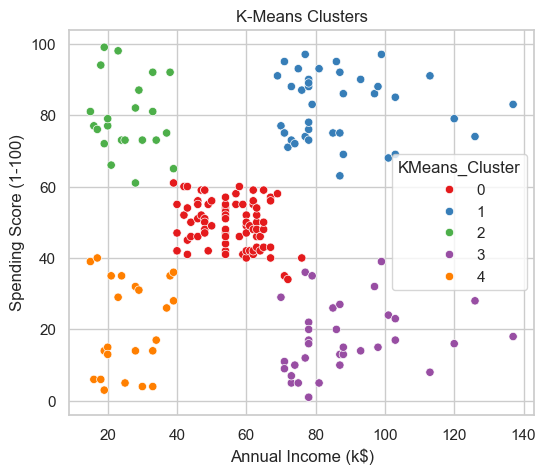

In [18]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='Annual Income (k$)', 
                y='Spending Score (1-100)', 
                hue='KMeans_Cluster', 
                palette='Set1',
                data=df)

plt.title("K-Means Clusters")
plt.show()

In [19]:
score_kmeans = silhouette_score(X_scaled, df['KMeans_Cluster'])
print("K-Means Silhouette Score:", score_kmeans)

K-Means Silhouette Score: 0.5546571631111091


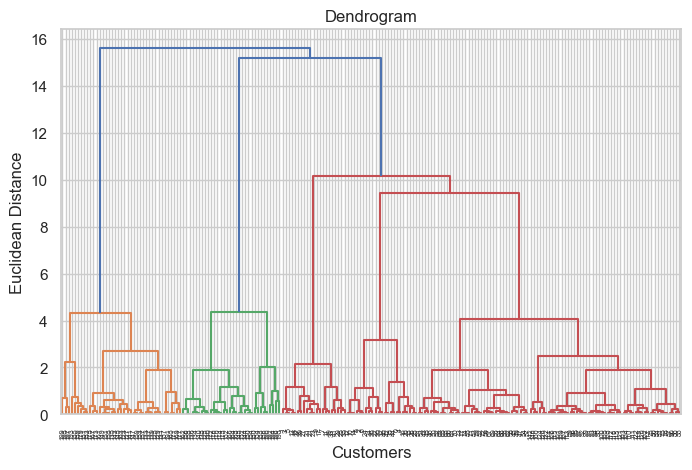

In [20]:
plt.figure(figsize=(8,5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

In [21]:
hc = AgglomerativeClustering(n_clusters=5)
df['HC_Cluster'] = hc.fit_predict(X_scaled)

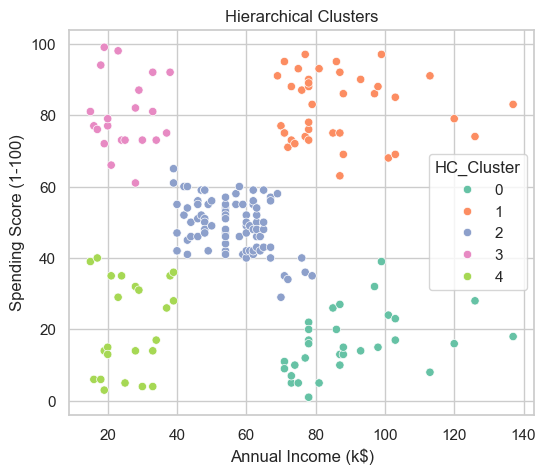

In [22]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='Annual Income (k$)', 
                y='Spending Score (1-100)', 
                hue='HC_Cluster', 
                palette='Set2',
                data=df)

plt.title("Hierarchical Clusters")
plt.show()

In [23]:
score_hc = silhouette_score(X_scaled, df['HC_Cluster'])
print("Hierarchical Silhouette Score:", score_hc)

Hierarchical Silhouette Score: 0.5538089226688662


In [24]:
print("K-Means Silhouette Score:", score_kmeans)
print("Hierarchical Silhouette Score:", score_hc)

K-Means Silhouette Score: 0.5546571631111091
Hierarchical Silhouette Score: 0.5538089226688662


In [25]:
df.groupby('KMeans_Cluster')[['Annual Income (k$)','Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043
